# QA extractivo con BERT: experimento ejecutado

Una pregunta y su contexto entran juntos a BERT. Dos salidas asignan puntuaciones a cada token: una para el inicio y otra para el final de la respuesta. Este notebook inspecciona evidencia de un entrenamiento real realizado con `src/qa_experiment.py`; ejecutarlo no reentrena silenciosamente.

**Hipótesis previa:** adaptar todo BERT puede mejorar F1, pero requiere más recursos. Comparación: últimas 2 capas+cabeza frente a ajuste completo. Tres épocas; seed 42. La selección usa validación interna independiente por artículo.

In [1]:
from pathlib import Path
import json, pandas as pd, matplotlib.pyplot as plt
ROOT=Path.cwd()
if not (ROOT/'runs').exists(): ROOT=ROOT.parent
RUN=ROOT/'runs'/'qa_verified'
read=lambda name:json.loads((RUN/name).read_text(encoding='utf-8'))
assert read('status.json')['status']=='completed'
read('config.json')

{'seed': 42,
 'epochs': 3,
 'train_size': 15000,
 'eval_size': 2000,
 'max_length': 384,
 'stride': 128,
 'micro_batch': 4,
 'accumulation': 4,
 'top_layers': 2,
 'head_lr': 0.001,
 'backbone_lr': 2e-05,
 'model_id': 'google-bert/bert-base-uncased',
 'dataset_id': 'rajpurkar/squad',
 'model_revision': '86b5e0934494bd15c9632b12f734a8a67f723594',
 'dataset_revision': '7b6d24c440a36b6815f21b70d25016731768db1f',
 'smoke': False,
 'attention_backend': 'sdpa',
 'gradient_checkpointing': False,
 'n_best': 20,
 'max_answer_length': 30}

## Datos y ventanas
Reservamos artículos completos para validación interna. Prueba proviene de validation oficial de SQuAD. Un contexto largo produce varias ventanas; la respuesta íntegra puede aparecer en alguna ventana y las otras reciben CLS. Los tokens de pregunta/padding nunca son candidatos al decodificar.

In [2]:
manifest=read('split_manifest.json')
print({k:manifest[k] for k in ['sizes','features','context_overlap','split_policy']})
read('span_coverage.json')

{'sizes': {'train': 15000, 'validation': 2000, 'test': 2000}, 'features': {'train': 15159, 'validation': 2026, 'test': 2030}, 'context_overlap': 0, 'split_policy': '15% of official train article titles reserved for internal validation; official validation reserved for test; sample questions seed42'}


{'train': {'examples_with_supervised_gold_span_at_most_30_tokens': 14965,
  'total_examples': 15000,
  'negative_windows': 126},
 'validation': {'examples_with_supervised_gold_span_at_most_30_tokens': 1994,
  'total_examples': 2000,
  'negative_windows': 20},
 'test': {'examples_with_supervised_gold_span_at_most_30_tokens': 2000,
  'total_examples': 2000,
  'negative_windows': 24}}

## Resultados y selección
Exact match y F1 van de 0 a 100. F1 aquí compara tokens de respuesta, no entidades como NER. El máximo sobre referencias válidas evita penalizar variantes anotadas. Sólo se consultó prueba después de elegir el método.

In [3]:
results=pd.DataFrame(read('comparison.json'))
display(results)
read('selection.json')

,method,best_epoch,best_val_f1,trainable_parameters,total_parameters,frozen_parameters_verified,train_seconds,peak_allocated_gpu_bytes,test_exact_match,test_f1,test_loss,selected
0,partial_finetuning,3,58.373018,14177282,108893186,True,305.736571,838847488,47.8,61.749065,1.926297,False
1,full_finetuning,3,77.282498,108893186,108893186,False,845.982594,2699117056,73.6,83.277402,1.262567,True


{'winner': 'full_finetuning',
 'criterion': 'internal validation token F1; exact tie fewer parameters',
 'test_used_for_selection': False,
 'single_seed': True,
 'smoke': False}

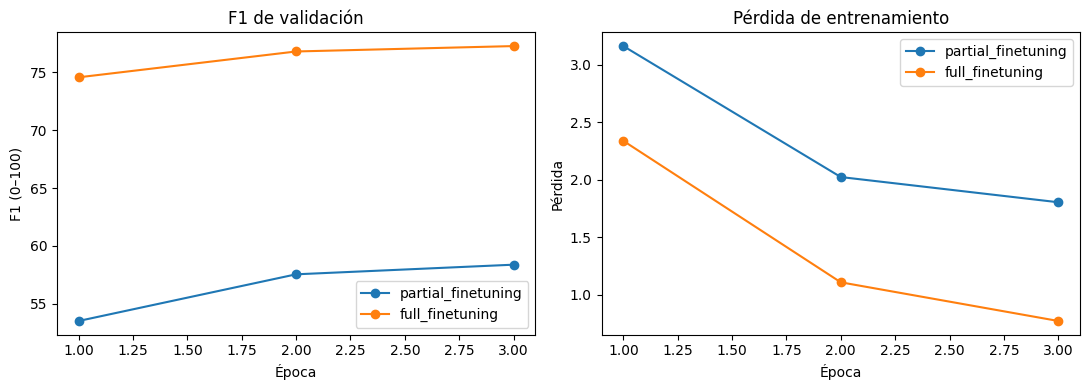

In [4]:
fig,axes=plt.subplots(1,2,figsize=(11,4))
for method in results.method:
 h=pd.DataFrame(read(method+'/history.json'))
 axes[0].plot(h.epoch,h.val_f1,marker='o',label=method)
 axes[1].plot(h.epoch,h.train_loss,marker='o',label=method)
axes[0].set(title='F1 de validación',xlabel='Época',ylabel='F1 (0–100)')
axes[1].set(title='Pérdida de entrenamiento',xlabel='Época',ylabel='Pérdida')
axes[0].legend();axes[1].legend();plt.tight_layout();plt.show()

## Errores y límites
Revisar una respuesta incorrecta ayuda a detectar límites incompletos o selección de otro fragmento. No demuestra por sí solo por qué el modelo cometió el error. Una semilla y un subconjunto no establecen rendimiento general. SQuAD 1.1 siempre espera una respuesta y no evalúa abstención.

In [5]:
winner=read('selection.json')['winner']
errors=read(winner+'/error_analysis.json')
print({k:v for k,v in errors.items() if k!='examples'})
display(pd.DataFrame(errors['examples'])[['question','references','prediction','f1']].head(10))
read('reload_verification.json')

{'zero_f1': 186, 'partial_f1': 342}


,question,references,prediction,f1
0,What is an example of an article of uniform cl...,"[blazer, blazer, blazer]",a compulsory blazer,0.666667
1,How did Vaudreuil react when Johnson was seen ...,[sent Dieskau to Fort St. Frédéric to meet tha...,"larger threat, Vaudreuil sent Dieskau to Fort ...",0.869565
2,How many yards did Newton throw for in 2015?,"[3,837, 3,837, 3,837]","3,837 yards and rushing for 636",0.285714
3,Why is the collection dominated by fashionable...,[Because everyday clothing from previous eras ...,Because everyday clothing from previous eras,0.750000
4,What was Thoreau's punishment for not paying h...,"[imprisonment, imprisonment, imprisonment, imp...",Resign,0.000000
5,To force Japan to be more involved in the cris...,"[5% production cut, declared Japan a ""nonfrien...",encourage it to change its noninvolvement policy,0.000000
6,How many people were in French North American ...,"[roughly 60,000 European settlers, 60,000, 60,...","60,000 European settlers, compared with 2 million",0.600000
7,What field of computer science analyzes the re...,"[analysis of algorithms, analysis of algorithm...",analysis of algorithms and computability theory,0.666667
8,What would a teacher do for someone who is timid?,"[encourage, encourage, encourage]","encourage the timid, detect and correct indivi...",0.250000
9,What is a chlorenchyma cell?,"[A plant cell which contains chloroplasts, cel...",A typical chlorenchyma cell of a land plant co...,0.470588


{'all_test_predictions_identical': True,
 'scores': {'exact_match': 73.6,
  'f1': 83.27740228969499,
  'loss': 1.2625670313247905},
 'verification_recovered_with_explicit_utf8': True}

## Ejemplo del modelo exportado
Predicciones reales para un contexto breve; este ejemplo ilustra el uso y no reemplaza la evaluación de prueba.

In [6]:
read('demo.json')

{'context': 'The office is in London. It opened in 2020.',
 'examples': [{'question': 'Where is the office?', 'prediction': 'London'},
  {'question': 'When did the office open?', 'prediction': '2020'}]}

## Reproducir y entregar
Consultar `QA_GUIDE.md`, script y versiones exactas. El modelo y tokenizer elegidos están en `runs/qa_verified/delivered_model_qa`; no se publicaron automáticamente. Los registros incluyen predicciones y referencias completas, configuración, revisiones, tiempos y hash de parámetros congelados verificado.

Fuentes: [SQuAD](https://huggingface.co/datasets/rajpurkar/squad), [evaluación oficial](https://github.com/rajpurkar/SQuAD-explorer/blob/master/evaluate-v1.1.py), [BERT base uncased](https://huggingface.co/google-bert/bert-base-uncased).